# Filtering and Trimming Messages

In [1]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3.5",
    temperature=.8,
    max_retries=3
)


d:\workspace\AI\langchain-academy\langgraph-foundation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


In [3]:
response = llm.invoke(messages)

response.pretty_print()

================================== Ai Message ==================================

That is a great starting point! While whales are the most famous, the ocean is home to several other distinct families of mammals. Here are the main groups you should definitely learn about next:

### 1. Pinnipeds (The "Fin-Footed" Seals)
This group includes three distinct types, often confused by the general public:
*   **True Seals:** They lack external ear flaps and move on land using a "belly crawl." They are often found in colder Arctic and Antarctic waters.
*   **Eared Seals (Sea Lions & Fur Seals):** You can tell them apart because they have external ear flaps. They are stronger swimmers and can use their front flippers to "walk" on land.
*   **Walruses:** The largest pinnipeds, famous for their long tusks and whiskers (vibrissae), which help them find clams on the ocean floor.

### 2. Sirenians (Sea Cows)
*   **Manatees & Dugongs:** These are the ocean's gentlest herbivores. They eat seagrass and 

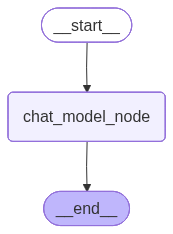

In [4]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

builder = StateGraph(MessagesState)
builder.add_node(chat_model_node)
builder.add_edge(START, "chat_model_node")
builder.add_edge("chat_model_node", END)
graph = builder.compile()
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
output = graph.invoke({"messages": messages})

for m in output["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That is a great starting point! Since you know about whales, you might not know that there are actually **four main groups** of marine mammals. Whales are just one of them.

Here are the other groups you should learn about:

### 1. Pinnipeds (Ear Seals)
These are the "eared" sea mammals. Unlike whales, they have hind legs that can rotate (allowing them to walk on land).
*   **Seals:** Usually have small ear holes (hard to see) and flatter faces. They are often found in cold water.
*   **Sea Lions:** Have visible ear holes and larger front flippers. They are known for their barking sounds.
*   **Walruses:** These 

## Reducers

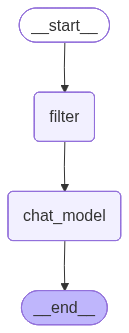

In [6]:
from langchain_core.messages import RemoveMessage

llm = ChatOllama(
    model="qwen3.5",
    temperature=.8,
    max_retries=3
)


def filter_messages(state: MessagesState):
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}


# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({"messages": messages})

for m in output['messages']:
    m.pretty_print()

KeyboardInterrupt: 

## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.


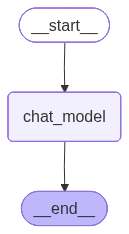

In [ ]:
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's awesome! Since you're already familiar with whales, you have a great foundation to build on. There are actually several other distinct families of ocean mammals you should explore to get a complete picture of marine life.

Here are the main groups you should learn about:

**1. Pinnipeds (The "Seals")**
*   **True Seals (Earless Seals):** Look for the Weddell seal or the Harp seal. Unlike sea lions, they cannot rotat

In [ ]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's awesome! Since you're already familiar with whales, you have a great foundation to build on. There are actually several other distinct families of ocean mammals you should explore to get a complete picture of marine life.

Here are the main groups you should learn about:

**1. Pinnipeds (The "Seals")**
*   **True Seals (Earless Seals):** Look for the Weddell seal or the Harp seal. Unlike sea lions, they cannot rotat

## Trim Messages

Another approach is to trim messages, based upon a set number of tokens.

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.


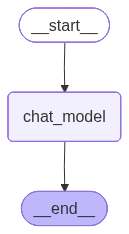

In [ ]:
from langchain_core.messages import trim_messages

def chat_model_node(state: MessagesState):
    messages = trim_messages(
        state["messages"],
        max_tokens=100,
        strategy="last",
        token_counter=ChatOllama(model="qwen3.5"),
        allow_partial=False
    )
    return {"messages":[llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [ ]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

ImportError: Could not import transformers python package. This is needed in order to calculate get_token_ids. Please install it with `pip install transformers`.

# Trim messages using Ollama

In [9]:
very_long_text ="""
That's awesome! Since you're already familiar with whales, you have a great foundation to build on. There are actually several other distinct families of ocean mammals you should explore to get a complete picture of marine life.

Here are the main groups you should learn about:

**1. Pinnipeds (The "Seals")**
*   **True Seals (Earless Seals):** Look for the Weddell seal or the Harp seal. Unlike sea lions, they cannot rotate their hind flippers and cannot walk on land (they can only drag themselves).
*   **Sea Lions & Fur Seals:** These have external ear flaps. They can walk on land and are known for being very vocal (barking).
*   **Walruses:** These are massive pinnipeds known for their tusks and their ability to walk on their knees while dragging themselves over ice.

**2. Sirenians (The Gentle Giants)**
*   **Manatees and Dugongs:** These are the closest living relatives to the extinct Steller's sea cow. Unlike whales or seals, they are herbivores (eating sea grass) and move very slowly. They are often called "sea cows."

**3. Sea Otters**
*   Unlike most marine mammals, they do not have blubber to keep warm; instead, they have incredibly dense fur. They are also one of the few marine mammals that use tools (using rocks to crack open shellfish). They are also an important keystone species in kelp forests.

**4. Polar Bears**
*   While they spend most time on land, polar bears are the only bear species that spends a significant amount of time on the water. They are excellent swimmers and hunt seals on sea ice.

**5. Other Cetaceans (Whale Relatives)**
*   **Orcas (Killer Whales):** Despite their name, they are actually dolphins (the largest). They are highly intelligent and have distinct "cultures" and dialects.
*   **Porpoises:** Smaller cousins of dolphins and whales, often found in cooler waters.
*   **Narwhals:** Often called the "unicorn of the sea" because of their long spiral tusk (which is actually a tooth).

**6. Deep Divers**
*   **Sperm Whales:** While you know about whales, sperm whales are fascinating because of their deep diving capabilities (up to 2,200 meters) and their massive ears for detecting prey.

**Suggestion for your research:**
Pick one of these groups to dive deep into. For example, research the **Sea Otter** to learn about their role in protecting kelp forests, or look into **Narwhals** to learn about how they survive the Arctic ice.

Which of these groups sounds the most interesting to you?
================================ Human Message =================================
Name: Lance

Tell me more about Narwhals!
================================== Ai Message ==================================

The narwhal (*Monodon monoceros*) is one of the most fascinating and mysterious creatures in the world's oceans. Often called the **"Unicorns of the Sea,"** they are known for their long, spiraled "tusk."

Here is a deep dive into everything you need to know about these amazing Arctic whales.

### 1. What is the "Tusk"?
This is the most famous feature of the narwhal, but it is often misunderstood.
*   **It's a tooth:** The "tusk" is actually a massively elongated **incisor tooth** (specifically the left upper canine). It is made of dentin, the same material as your tooth enamel and your fingernails.
*   **Why only one side?** In males, the tusk grows on the left side. In females, the tusk is often smaller and may grow on both sides (or be hidden under the lip).
*   **Purpose:** Scientists are still debating exactly why they have it. Theories include:
    *   **Social Status:** In the ocean, the larger tusk may be used to establish dominance during mating rituals.
    *   **Sensing:** It is highly sensitive and can be used to detect changes in water pressure, temperature, or salinity (similar to how a shark's lateral line works).
    *   **Defense:** It can be used as a weapon to deter predators like polar bears or killer whales.

### 2. Habitat and Range
Narwhals live in the **Arctic Ocean** and the seas surrounding it.
*   **Locations:** They can be found in the Barents Sea, the waters around Greenland, Svalbard (Norway), and Hudson Bay (Canada).
*   **Migration:** They are migratory. In summer, they move north toward the North Pole to feed. In winter, they migrate south to avoid the freezing ice and hunting grounds that rely on ice.
*   **Sea Ice:** They are dependent on sea ice. They hunt under the ice and breathe through the small holes they create in the ice. As climate change melts the ice, narwhals face new challenges.

### 3. Diet
Narwhals are **benthic feeders**, meaning they eat prey living on or near the sea floor.
*   **What they eat:** They primarily eat **squat**, shrimp, and fish (like cod and hake).
*   **Diving:** They are incredible divers. They can dive to depths of over **1,500 meters (4,900 feet)** and stay underwater for up to **20 minutes** at a time.

### 4. Social Structure
Narwhals live in small, stable pods.
*   **Pod Size:** They usually travel in groups of 5 to 15 individuals, though they can form larger groups when migrating.
*   **Family Units:** The pods usually consist of a female (matriarch), her offspring (calves), and a male.
*   **Communication:** They communicate using **clicks** and whistles. Interestingly, male narwhals have a higher-pitched call than females.

### 5. Conservation Status
Narwhals are currently listed as **Vulnerable** on the IUCN Red List.
*   **Threats:**
    *   **Climate Change:** Melting sea ice reduces their hunting grounds and forces them into more crowded areas.
    *   **Pollution:** They are affected by plastic pollution and oil spills.
    *   **Ship Traffic:** Noise pollution from shipping vessels can disrupt their communication and navigation.
    *   **Fishing Gear:** They can accidentally get caught in fishing nets (bycatch).
*   **Populations:** There are two distinct populations: the West Greenland population (smaller) and the East Greenland population (larger).

### 6. Fun Facts
*   **Color:** Narwhals are not white; they are a silvery-white. However, they can turn gray or brown as they age.
*   **Skin:** Their skin is very thin and lacks a blubber layer, which is unique among whales. This helps them regulate temperature but makes them more susceptible to cold.
*   **Circulation:** They have a unique blood circulation system that prevents their blood from freezing in the cold Arctic waters.
*   **Longevity:** They can live up to 50 years.

### Why They Matter
Narwhals are the **barometers of Arctic health**. Because they live in the most remote and pristine parts of the ocean, their population health gives scientists a direct look into how climate change is affecting the Arctic ecosystem.

If you ever find yourself near the Arctic coast, keep an eye out for them—they are a magical reminder of the delicate balance of our planet's oceans!
"""

In [21]:
from langchain_ollama import ChatOllama
from langchain_core.messages import trim_messages, HumanMessage, AIMessage

llm = ChatOllama(model="llama3.2")

def ollama_token_counter(messages):
    return llm.get_num_tokens(str(messages))

messages = [
    HumanMessage(content="Hello"),
    AIMessage(content="Hello! How can I help?"),
    HumanMessage(content=f"Summarize this text... \n {very_long_text}")
]

trimmed_messages = trim_messages(
    messages,
    max_tokens=1000,
    token_counter=ollama_token_counter,
    strategy="last",
    include_system=True,
    allow_partial=True
)

In [23]:
for m in trimmed_messages:
    m.pretty_print()

================================ Human Message =================================

*   **Why only one side?** In males, the tusk grows on the left side. In females, the tusk is often smaller and may grow on both sides (or be hidden under the lip).
*   **Purpose:** Scientists are still debating exactly why they have it. Theories include:
    *   **Social Status:** In the ocean, the larger tusk may be used to establish dominance during mating rituals.
    *   **Sensing:** It is highly sensitive and can be used to detect changes in water pressure, temperature, or salinity (similar to how a shark's lateral line works).
    *   **Defense:** It can be used as a weapon to deter predators like polar bears or killer whales.

### 2. Habitat and Range
Narwhals live in the **Arctic Ocean** and the seas surrounding it.
*   **Locations:** They can be found in the Barents Sea, the waters around Greenland, Svalbard (Norway), and Hudson Bay (Canada).
*   **Migration:** They are migratory. In summer, the